# 1. Overview

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from itertools import combinations
from functools import reduce
import os
import math
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, pearsonr
from matplotlib.colors import LinearSegmentedColormap

# 2. Load Dataset

In [2]:
companyInfo = pd.read_csv("company_info.csv")
monashIndex = pd.read_csv("monashIndex.csv")
stockData = pd.read_csv("stock_data.csv")
testing = pd.read_csv("testing_targets.csv")
training = pd.read_csv("training_targets.csv")
funds = pd.read_csv("fed_funds_rate.csv")
inflation = pd.read_csv("fed_inflation_rate.csv")
unemployment = pd.read_csv("fed_unemployment_rate.csv")
fiveyearT = pd.read_csv("us_5_year_treasury.csv")
tenyearT = pd.read_csv("us_10_year_treasury.csv")
vixIndex = pd.read_csv("vix_index.csv")

# 3.Exploration Data Analysis

## 3.1. Company Info

In [3]:
companyInfo.describe()

,stock_id,sector,business_model,geographic_focus,business_maturity,competitive_position,market_cap_category,revenue_tier,profitability_profile,asset_intensity,financial_strength
count,616,616,616,616,616,616,616,616,616,616,616
unique,616,12,3,3,3,3,3,3,3,3,3
top,US650,Technology,B2C,Global,Mature,Strong_Player,Mid,Tier_2,Standard,Moderate,Stable
freq,1,100,294,285,316,362,374,374,329,300,265


In [4]:
companyInfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   stock_id               616 non-null    object
 1   sector                 616 non-null    object
 2   business_model         616 non-null    object
 3   geographic_focus       616 non-null    object
 4   business_maturity      616 non-null    object
 5   competitive_position   616 non-null    object
 6   market_cap_category    616 non-null    object
 7   revenue_tier           616 non-null    object
 8   profitability_profile  616 non-null    object
 9   asset_intensity        616 non-null    object
 10  financial_strength     616 non-null    object
dtypes: object(11)
memory usage: 53.1+ KB


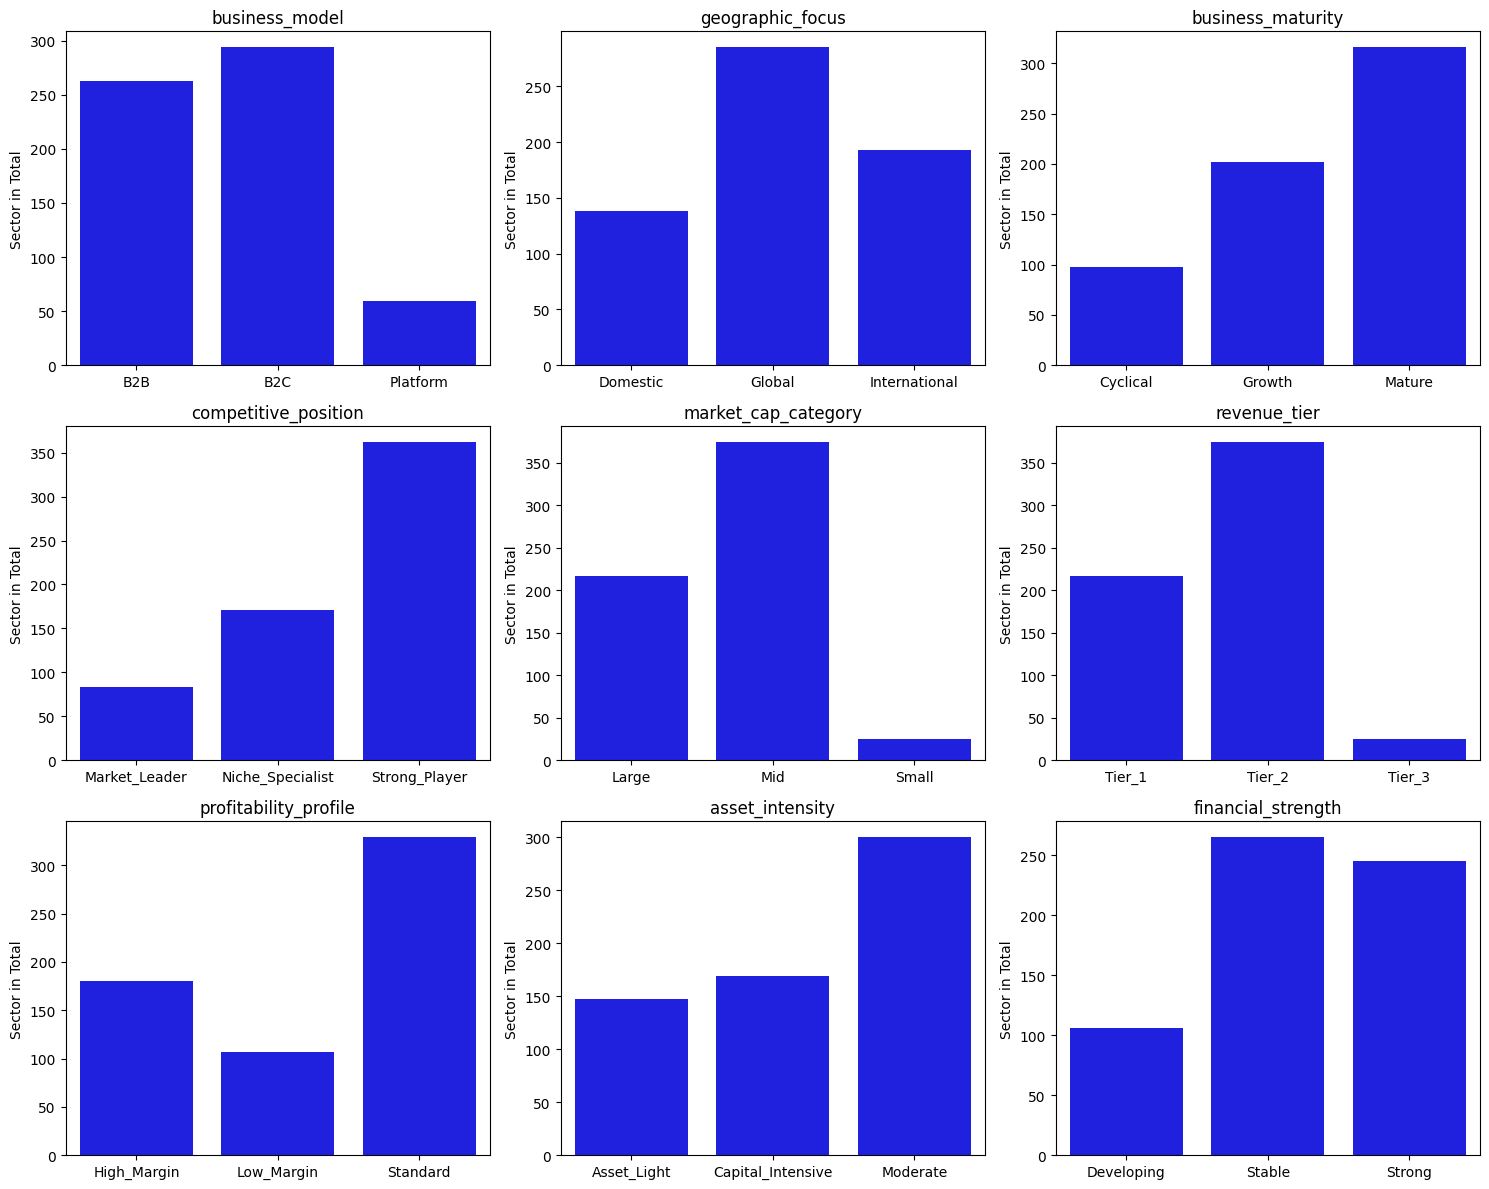

In [5]:
exclude_cols = ['stock_id', 'sector']
cat_cols = [col for col in companyInfo.columns 
            if companyInfo[col].dtype == 'object' and col not in exclude_cols]

n = len(cat_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = companyInfo[col].value_counts().sort_index()
    sns.barplot(x=vc.index, y=vc.values, ax=axes[i], color="blue")  
    axes[i].set_title(col)
    axes[i].set_ylabel("Sector in Total")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x")

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

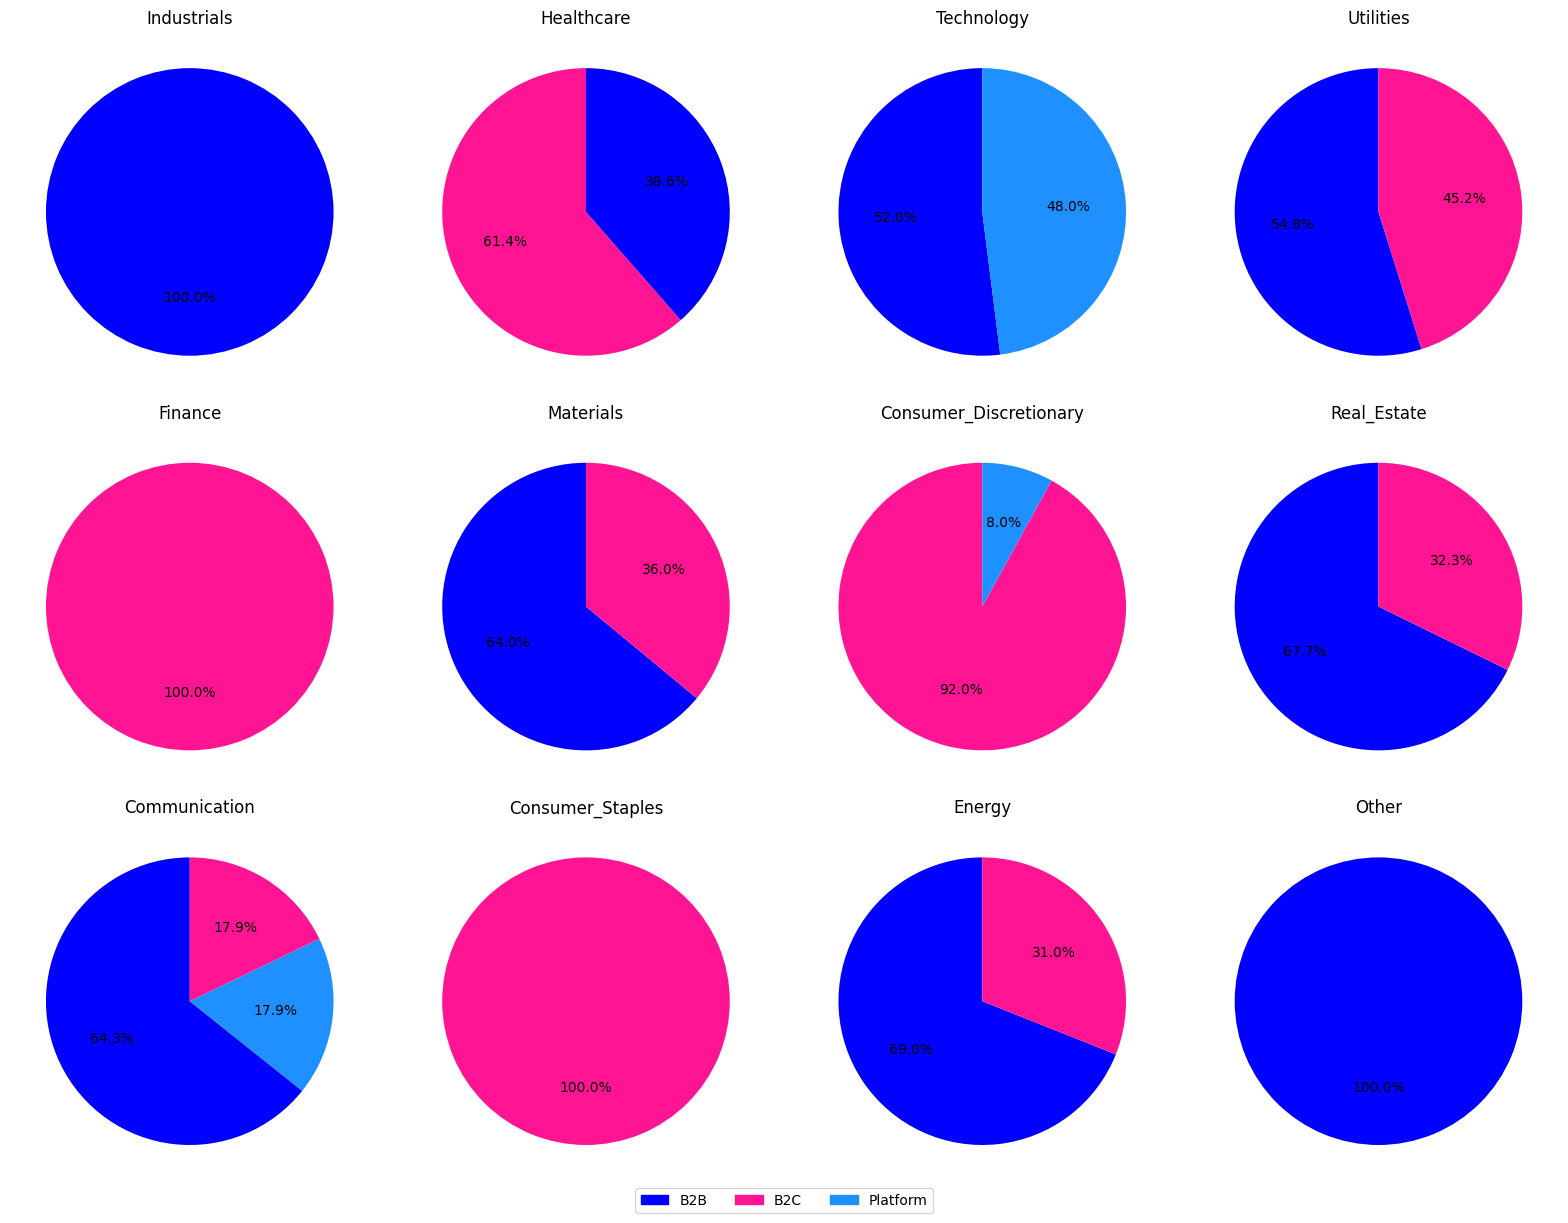

In [6]:
# Get unique sectors
sectors = companyInfo['sector'].unique()
n_sectors = len(sectors)

# Unique business models for consistent colors
business_models = companyInfo['business_model'].dropna().unique()
custom_colors = ["blue",  # deep blue
                 "deeppink",  # hot pink
                 "dodgerblue"]  # skyblue 
color_map = {bm: custom_colors[i % len(custom_colors)] for i, bm in enumerate(business_models)}

# Set up subplot grid
cols = 4
rows = math.ceil(n_sectors / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, sector in enumerate(sectors):
    subset = companyInfo[companyInfo['sector'] == sector]
    counts = subset['business_model'].value_counts()

    # Map colors according to business model
    pie_colors = [color_map[bm] for bm in counts.index]

    axes[i].pie(
        counts, labels=None, autopct='%1.1f%%', startangle=90, colors=pie_colors
    )
    axes[i].set_title(sector)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Create a single legend outside the plots
handles = [plt.matplotlib.patches.Patch(color=color_map[bm], label=bm) for bm in business_models]
fig.legend(handles=handles, loc='lower center', ncol=len(business_models), bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()


In [7]:
# Helper: compute Cramér's V with bias correction
def cramers_v_from_crosstab(ct):
    chi2, p, dof, expected = chi2_contingency(ct, correction=False)
    n = ct.values.sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2corr / denom)

In [8]:
# Identify categorical columns (exclude stock_id if it's an identifier)
cat_cols = [c for c in companyInfo.columns if companyInfo[c].dtype == 'object' or str(companyInfo[c].dtype) == 'category']
if "stock_id" in cat_cols: cat_cols.remove("stock_id")

# Compute full Cramér's V matrix
cv_mat = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for a, b in combinations(cat_cols, 2):
    ct = pd.crosstab(companyInfo[a], companyInfo[b])
    v = cramers_v_from_crosstab(ct)
    cv_mat.loc[a, b] = v  # Only fill one side

# Optionally fill diagonal with 1.0
np.fill_diagonal(cv_mat.values, 1.0)

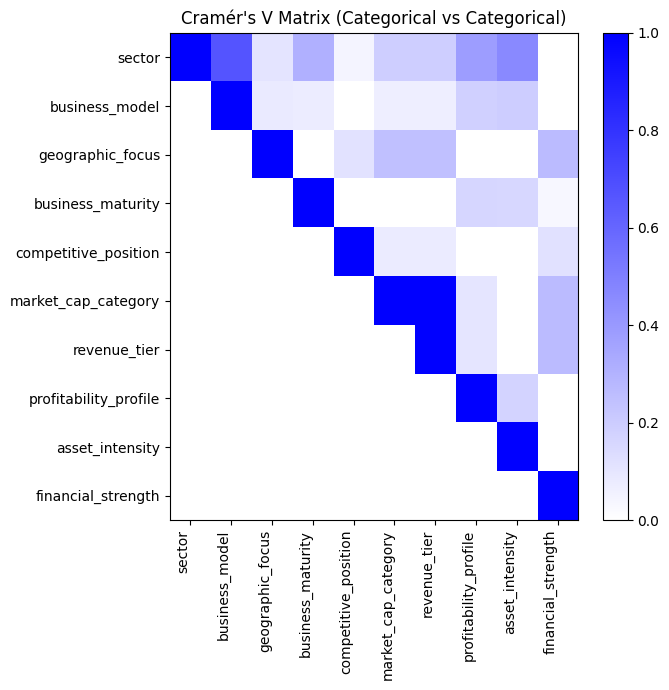

In [9]:
# Create custom colormap from white → DeepSkyBlue
cmap = LinearSegmentedColormap.from_list(
    "custom_skyblue",
    ["#FFFFFF", "blue"])

plt.figure(figsize=(1+0.6*len(cat_cols), 1+0.6*len(cat_cols)))
plt.imshow(cv_mat.values, aspect='auto', cmap=cmap)
plt.colorbar()
plt.xticks(ticks=np.arange(len(cat_cols)), labels=cat_cols, rotation=90, ha="right")
plt.yticks(ticks=np.arange(len(cat_cols)), labels=cat_cols)
plt.title("Cramér's V Matrix (Categorical vs Categorical)")
plt.tight_layout()
plt.show()

In [10]:
# Save ranked pairs
pairs = (
    cv_mat.where(~np.eye(cv_mat.shape[0], dtype=bool))
    .stack()
    .reset_index()
)
pairs.columns = ["attr_A", "attr_B", "cramers_v"]
pairs = pairs.dropna().sort_values("cramers_v", ascending=False)

pairs.head(10)

,attr_A,attr_B,cramers_v
35,market_cap_category,revenue_tier,1.000000
0,sector,business_model,0.669655
7,sector,asset_intensity,0.462626
6,sector,profitability_profile,0.384911
2,sector,business_maturity,0.309570
23,geographic_focus,financial_strength,0.266918
38,market_cap_category,financial_strength,0.265826
41,revenue_tier,financial_strength,0.265826
20,geographic_focus,revenue_tier,0.249726
19,geographic_focus,market_cap_category,0.249726


## 3.2. Stock Data

In [11]:
stockData.describe()

,month_start_open_usd,month_end_close_usd,month_high_usd,month_low_usd,monthly_volume,intramonth_return,return_1m,return_3m,return_6m,intramonth_volatility,volatility_3m,volatility_6m,trading_days,avg_volume_3m,volume_ratio,price_range_ratio
count,25618.000000,25618.000000,25618.000000,25618.000000,2.561800e+04,25618.000000,25597.000000,25555.000000,25483.000000,25616.000000,25555.000000,25483.000000,25618.000000,2.557600e+04,25576.000000,25618.000000
mean,133.718601,134.509803,144.473964,123.620124,1.247736e+08,0.012421,0.014740,0.042243,0.093739,0.384489,0.337133,0.356375,20.944414,5.641095e+06,1.005413,0.175590
std,245.900862,248.289855,263.700953,229.767331,4.721806e+08,0.126536,0.125580,0.224537,0.397024,0.253038,0.280432,0.240778,1.194822,2.094349e+07,0.209451,0.126633
min,0.700000,0.710000,0.997000,0.463000,1.500000e+03,-0.836003,-0.832263,-0.891459,-0.878101,0.037019,0.001361,0.020767,0.000000,1.440000e+02,0.046000,0.010922
25%,40.769500,40.839000,44.319250,37.065500,2.026318e+07,-0.054867,-0.053000,-0.073179,-0.093493,0.230496,0.174882,0.220319,20.000000,9.438960e+05,0.870000,0.101960
50%,78.925000,79.129000,85.501500,72.607500,4.413910e+07,0.006757,0.010027,0.026508,0.054570,0.312991,0.276629,0.300236,21.000000,2.040366e+06,0.984000,0.142549
75%,156.383750,157.484000,168.718750,144.102500,1.046730e+08,0.070576,0.073907,0.137254,0.220102,0.450122,0.420836,0.420214,22.000000,4.773016e+06,1.111000,0.207368
max,5870.000000,6350.620000,6386.620000,5528.090000,1.585655e+10,3.257143,3.197183,6.892996,19.942211,3.458247,7.123194,4.904750,23.000000,6.000172e+08,2.602000,3.457143


### 3.2.1. Handling Missing Value

In [12]:
# Detecting the number of missing values
stockData.isnull().values.sum()

np.int64(503)

In [13]:
# Count NaN values per column
na_count = stockData.isna().sum()
# Keep only columns with at least one NaN
summary = pd.DataFrame({"na_count": na_count[na_count > 0]})
print(summary)

                       na_count
return_1m                    21
return_3m                    63
return_6m                   135
intramonth_volatility         2
volatility_3m                63
volatility_6m               135
avg_volume_3m                42
volume_ratio                 42


In [14]:
stockData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25618 entries, 0 to 25617
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   stock_id               25618 non-null  object 
 1   month_id               25618 non-null  object 
 2   month_start_open_usd   25618 non-null  float64
 3   month_end_close_usd    25618 non-null  float64
 4   month_high_usd         25618 non-null  float64
 5   month_low_usd          25618 non-null  float64
 6   monthly_volume         25618 non-null  int64  
 7   intramonth_return      25618 non-null  float64
 8   return_1m              25597 non-null  float64
 9   return_3m              25555 non-null  float64
 10  return_6m              25483 non-null  float64
 11  intramonth_volatility  25616 non-null  float64
 12  volatility_3m          25555 non-null  float64
 13  volatility_6m          25483 non-null  float64
 14  trading_days           25618 non-null  int64  
 15  av

In [15]:
# Function to check expected missing based on position in each stock
def check_expected_missing(df, col, required_lags):
    """
    Flags missing values in a column and whether they are 'expected'
    because they occur within the first `required_lags` rows of each stock_id.
    """
    flagged = []
    for sid, grp in df.groupby("stock_id"):
        grp = grp.reset_index()  # preserve original index
        miss_idx = grp.index[grp[col].isna()]
        for idx in miss_idx:
            expected = idx < required_lags
            flagged.append({
                "stock_id": sid,
                "month_id": grp.loc[idx, "month_id"],
                "column": col,
                "expected_missing": expected
            })
    return pd.DataFrame(flagged)

# Define the rules
rules = {
    "return_1m": 1,
    "return_3m": 3,
    "volatility_3m": 3,
    "return_6m": 6,
    "volatility_6m": 6,
    "avg_volume_3m": 2,
    "volume_ratio": 2,
}

# Apply rules to build a report
reports = []
for col, lag in rules.items():
    if col in stockData.columns:
        rep = check_expected_missing(stockData, col, lag)
        reports.append(rep)

missing_report = pd.concat(reports, ignore_index=True)

# Show summary
summary = missing_report.groupby(["column","expected_missing"]).size().unstack(fill_value=0)

print("\nMissing Data Summary:\n", summary)



Missing Data Summary:
 expected_missing  True
column                
avg_volume_3m       42
return_1m           21
return_3m           63
return_6m          135
volatility_3m       63
volatility_6m      135
volume_ratio        42


In [16]:
# Fill ALL missing values with 0
stockData = stockData.fillna(0)
# Verify no NaN left
print("Remaining missing values or NaN: ", stockData.isna().values.sum())

Remaining missing values or NaN:  0


### 3.2.2. Handling Outlier using PCA

In [17]:
# ---------- Core: per-stock PCA reconstruction error ----------
def pca_recon_errors_per_stock(df: pd.DataFrame, n_components=None, z_thresh=3.0):
    """
    For each stock_id:
      1) standardize numeric columns
      2) fit PCA (keep n_components or all)
      3) compute reconstruction error
      4) compute z-scores of errors (per stock)
      5) flag outliers: z_score > z_thresh   (upper tail only)
    
    Returns:
      df_err  : tidy per-row errors with flags (all stocks)
      summary : counts of outliers per stock_id
    """
    # numeric columns only
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    drop_like = {"first_in_stock","first_record"}  # skip flags/identifiers if numeric
    numeric_cols = [c for c in numeric_cols if c not in drop_like]

    out_frames = []

    for sid, grp in df.groupby("stock_id"):
        if grp.empty:
            continue

        X = grp[numeric_cols].to_numpy()

        # Standardize
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)

        # PCA fit (use min(n_samples, n_features) if n_components is None)
        k = n_components if n_components is not None else min(Xs.shape)
        pca = PCA(n_components=k)
        Xp = pca.fit_transform(Xs)
        Xr = pca.inverse_transform(Xp)

        # Reconstruction error (L2 norm per row)
        err = np.sqrt(((Xs - Xr) ** 2).sum(axis=1))

        # z-scores per stock
        err_mean, err_std = err.mean(), err.std(ddof=0)
        z = (err - err_mean) / (err_std if err_std > 0 else 1.0)

        # flag outliers (upper tail only)
        is_out = z > z_thresh

        out_frames.append(pd.DataFrame({
            "stock_id": sid,
            "month_id": grp["month_id"].values,
            "recon_error": err,
            "recon_error_z": z,
            "is_outlier": is_out
        }))

    df_err = pd.concat(out_frames, ignore_index=True) if out_frames else pd.DataFrame(
        columns=["stock_id","month_id","recon_error","recon_error_z","is_outlier"]
    )

    summary = (
        df_err.groupby("stock_id")["is_outlier"]
        .sum()
        .rename("total_multivariate_outliers")
        .reset_index()
        .sort_values("total_multivariate_outliers", ascending=False)
    )

    return df_err, summary




In [18]:
# ---------- Plot: all datapoints in one scatter (outliers highlighted) ----------
def plot_pca_outliers_all(df_err: pd.DataFrame, z_thresh=3.0):
    """
    Scatter all rows (all stocks):
      x = month_id, y = recon_error_z, color = outlier
      Shows a constant threshold line at z_thresh
    """
    # If month_id is YYYY_MM string, keep as string for x-axis; or convert to datetime if you prefer ordering:
    # dt = pd.to_datetime(df_err["month_id"], format="%Y_%m", errors="coerce")
    # df_err = df_err.assign(month_id_dt=dt)
    # x_col = "month_id_dt"
    x_col = "month_id"

    plt.figure(figsize=(14,6))
    sns.scatterplot(
        data=df_err,
        x=x_col, y="recon_error_z",
        hue="is_outlier",
        palette={False: "blue", True: "red"},
        alpha=0.7, s=35
    )

    # Upper-tail threshold line at z_thresh
    plt.axhline(z_thresh, color="orange", linestyle="--", label=f"Threshold z>{z_thresh}")

    plt.title("PCA Reconstruction Error (z-score) — All Stocks")
    plt.xlabel("Month")
    plt.ylabel("Reconstruction Error (z-score)")
    plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

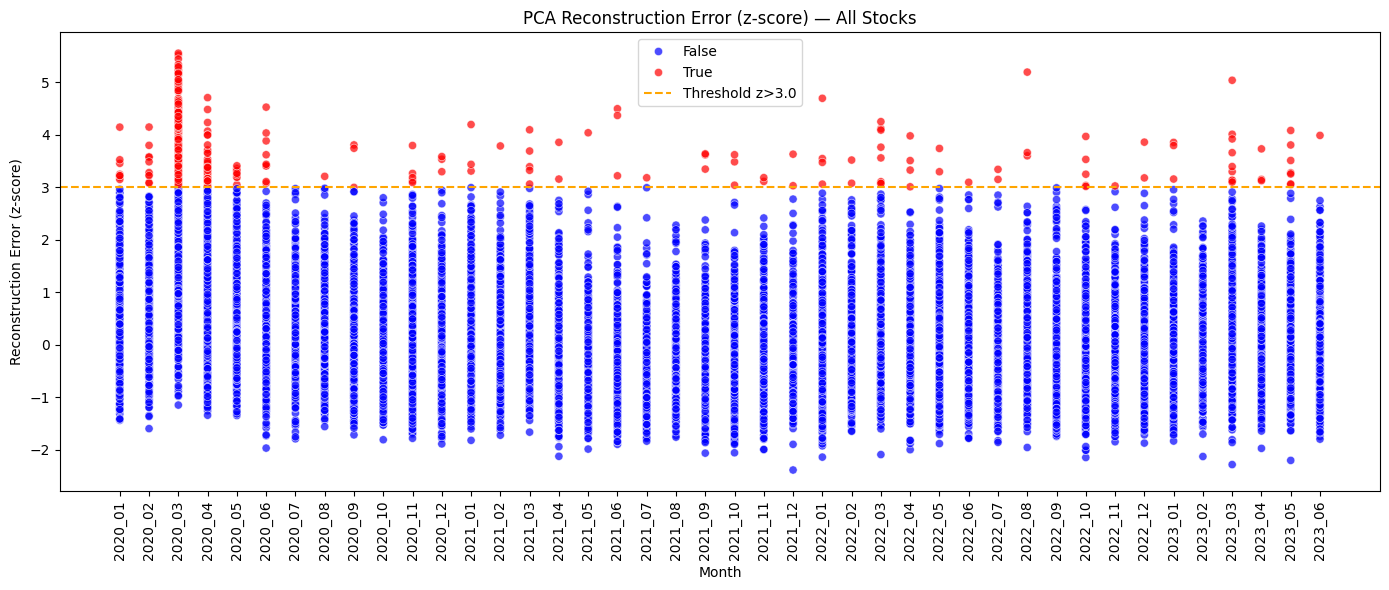

In [19]:
# plot the ourliers
df_err, pca_outlier_summary = pca_recon_errors_per_stock(stockData, n_components=None, z_thresh=3.0)
plot_pca_outliers_all(df_err, z_thresh=3.0)

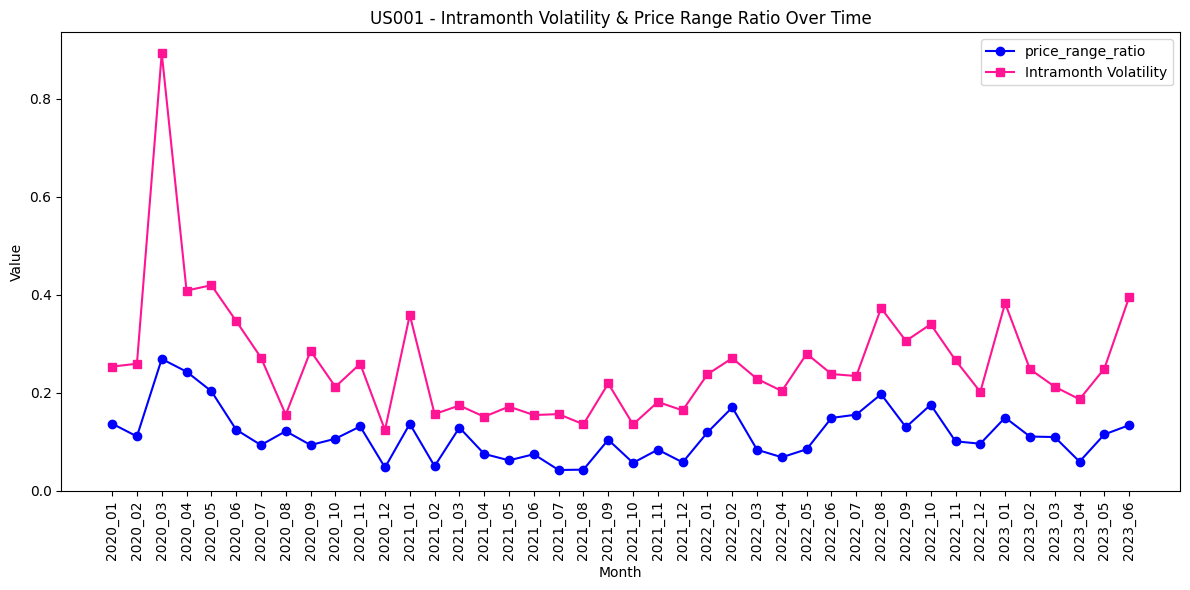

In [20]:
# Filter for US001
df_us001 = stockData[stockData["stock_id"] == "US001"].copy()

# Ensure month_id is sorted in time order
df_us001 = df_us001.sort_values("month_id")

# Plot
plt.figure(figsize=(12,6))
plt.plot(df_us001["month_id"], df_us001["price_range_ratio"], marker="o", color="blue", label="price_range_ratio")
plt.plot(df_us001["month_id"], df_us001["intramonth_volatility"], marker="s", color="deeppink", label="Intramonth Volatility")

plt.title("US001 - Intramonth Volatility & Price Range Ratio Over Time")
plt.xlabel("Month")
plt.ylabel("Value")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# 1. Identify outlier keys (stock_id and month_id) from df_err
outlier_keys = set(map(tuple, df_err.loc[df_err["is_outlier"], ["stock_id", "month_id"]].values))

# 2. Filter stockData to remove rows whose (stock_id, month_id) are in outlier_keys
mask = ~stockData[["stock_id", "month_id"]].apply(tuple, axis=1).isin(outlier_keys)
stockData_cleaned = stockData.loc[mask].reset_index(drop=True)

### 3.3.3. Data Rescaling and Transformation

In [22]:
skew_vals = stockData_cleaned.skew(numeric_only=True)
skew_vals

month_start_open_usd     11.878346
month_end_close_usd      11.974082
month_high_usd           11.758035
month_low_usd            12.107301
monthly_volume           18.138715
intramonth_return         2.457457
return_1m                 2.297113
return_3m                 3.913372
return_6m                12.394433
intramonth_volatility     2.636298
volatility_3m             5.380782
volatility_6m             4.964407
trading_days             -0.472016
avg_volume_3m            17.762006
volume_ratio              0.733282
price_range_ratio         5.146750
dtype: float64

In [23]:
# Separate columns
log_cols = skew_vals[skew_vals > 10].index.tolist()
std_cols = skew_vals[skew_vals <= 10].index.tolist()

In [24]:
# Copy dataset
stockData_transformed = stockData_cleaned.copy()

# Log-transform skewed columns
for col in log_cols:
    stockData_transformed[col] = np.log1p(stockData_transformed[col])

# Standardize the rest
scaler = StandardScaler()
stockData_transformed[std_cols] = scaler.fit_transform(stockData_transformed[std_cols])

In [25]:
stockData_transformed.describe()

,month_start_open_usd,month_end_close_usd,month_high_usd,month_low_usd,monthly_volume,intramonth_return,return_1m,return_3m,return_6m,intramonth_volatility,volatility_3m,volatility_6m,trading_days,avg_volume_3m,volume_ratio,price_range_ratio
count,25232.000000,25232.000000,25232.000000,25232.000000,25232.000000,2.523200e+04,2.523200e+04,2.523200e+04,25232.000000,2.523200e+04,2.523200e+04,2.523200e+04,2.523200e+04,25232.000000,2.523200e+04,2.523200e+04
mean,4.384344,4.390971,4.468956,4.302904,17.629409,-1.112335e-17,9.011322e-18,-2.337312e-17,0.048974,-1.847321e-16,2.252830e-16,5.181510e-17,1.174235e-15,14.540735,9.912454e-17,2.365472e-16
std,0.988605,0.988117,0.975971,0.997443,1.335804,1.000020e+00,1.000020e+00,1.000020e+00,0.286805,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.418238,1.000020e+00,1.000020e+00
min,0.530628,0.566450,0.691646,0.380489,7.313887,-6.679323e+00,-6.703089e+00,-4.224124e+00,-2.104562,-1.617236e+00,-1.214179e+00,-1.479063e+00,-1.694760e+01,0.000000,-4.923336e+00,-1.357266e+00
25%,3.736741,3.741905,3.816200,3.649534,16.817845,-5.571682e-01,-5.615777e-01,-5.219816e-01,-0.093178,-6.267973e-01,-5.816296e-01,-5.617745e-01,-7.974226e-01,13.750366,-6.397063e-01,-5.927849e-01
50%,4.383775,4.387704,4.462067,4.304342,17.592711,-4.998484e-02,-4.397483e-02,-7.739412e-02,0.053943,-2.752278e-01,-2.127303e-01,-2.271686e-01,5.258657e-02,14.520526,-7.710987e-02,-2.546914e-01
75%,5.060920,5.068923,5.134645,4.982706,18.452924,4.739431e-01,4.843325e-01,4.238982e-01,0.199425,2.952576e-01,3.066766e-01,2.713326e-01,9.025958e-01,15.370867,5.348372e-01,2.768015e-01
max,8.677780,8.756465,8.762117,8.617779,23.486849,2.694787e+01,2.656840e+01,3.124960e+01,3.041767,1.332562e+01,2.475286e+01,1.910043e+01,1.752605e+00,20.212469,7.917682e+00,2.778557e+01


# 3. Merging Data

In [26]:
df1 = [monashIndex, funds, inflation, unemployment, fiveyearT, tenyearT, vixIndex,training]
df1 = reduce(lambda left, right: pd.merge(left, right, on="month_id", how="left"), df1)

In [27]:
df1.describe()

,index_return,index_value,fed_rate,inflation_rate,unemployment_rate,5y_treasury,10y_treasury,vix,excess_return
count,25618.000000,25618.000000,25618.000000,25618.000000,25618.000000,25618.000000,25618.000000,25618.000000,25618.000000
mean,0.008250,123.375892,1.298869,4.703973,5.371337,1.810028,2.035616,23.883568,0.004170
std,0.044902,13.616227,1.758931,2.802350,2.648975,1.424554,1.157136,7.418166,0.109273
min,-0.111379,83.604709,0.050000,0.198201,3.400000,0.220000,0.540000,13.940000,-0.724624
25%,-0.012755,118.727903,0.080000,1.494040,3.600000,0.440000,1.090000,19.630000,-0.049809
50%,0.004782,127.634430,0.100000,5.181323,4.000000,1.190000,1.580000,22.370000,-0.001987
75%,0.032526,133.780082,2.330000,7.159457,6.200000,3.280000,3.130000,26.970000,0.050377
max,0.141313,139.438989,5.080000,8.999298,14.800000,4.250000,4.080000,57.740000,3.115830


In [28]:
# Columns unscale
id_and_target_cols = ['month_id', 'stock_id','excess_return']
# Columns to scale
num_cols = df1.columns.drop(id_and_target_cols)

# Scale numeric part
scaler = StandardScaler()
scaled = scaler.fit_transform(df1[num_cols])

# Build scaled DataFrame with identifiers + targets included
df1_scaled = pd.concat(
    [
        df1[id_and_target_cols].reset_index(drop=True),  # keep id + targets
        pd.DataFrame(scaled, columns=num_cols)
    ],
    axis=1
)

In [29]:
df1_scaled.describe()

,excess_return,index_return,index_value,fed_rate,inflation_rate,unemployment_rate,5y_treasury,10y_treasury,vix
count,25618.000000,2.561800e+04,2.561800e+04,2.561800e+04,2.561800e+04,2.561800e+04,2.561800e+04,2.561800e+04,2.561800e+04
mean,0.004170,-4.215883e-17,-1.819486e-16,5.325326e-17,1.708542e-16,-3.328329e-16,-6.212881e-17,2.041375e-16,2.485152e-16
std,0.109273,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00
min,-0.724624,-2.664311e+00,-2.920924e+00,-7.100299e-01,-1.607886e+00,-7.442030e-01,-1.116181e+00,-1.292541e+00,-1.340461e+00
25%,-0.049809,-4.678202e-01,-3.413633e-01,-6.929737e-01,-1.145466e+00,-6.687007e-01,-9.617433e-01,-8.172202e-01,-5.734101e-01
50%,-0.001987,-7.723356e-02,3.127607e-01,-6.816030e-01,1.703426e-01,-5.176959e-01,-4.352523e-01,-3.937526e-01,-2.040393e-01
75%,0.050377,5.406435e-01,7.641172e-01,5.862373e-01,8.762404e-01,3.128303e-01,1.031903e+00,9.457878e-01,4.160721e-01
max,3.115830,2.963477e+00,1.179725e+00,2.149718e+00,1.532788e+00,3.559433e+00,1.712831e+00,1.766796e+00,4.564078e+00


In [30]:
df2 = pd.merge(companyInfo, stockData_transformed, on=["stock_id"], how="left")
df2 = pd.merge(df2, df1_scaled, on=["month_id","stock_id"], how="left")

In [31]:
df2.shape

(25232, 37)

In [32]:
cols_to_move_end = ['excess_return']
cols_fixed = ['stock_id', 'month_id']

# All other columns (excluding fixed and move-to-end)
middle_cols = [c for c in df2.columns if c not in cols_fixed + cols_to_move_end]
# New order: stock_id, month_id, middle columns, then the target columns
new_order = cols_fixed + middle_cols + cols_to_move_end
# Reorder
df2 = df2[new_order]

In [33]:
def cramers_v(x, y):
    """Compute Cramér’s V for two categorical variables."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1))) if n > 0 else 0

In [34]:
def correlation_ratio(categories, values):
    """Compute correlation ratio (η) between a categorical and a numeric variable."""
    fcat, _ = pd.factorize(categories)
    cat_num = fcat.max() + 1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    for i in range(cat_num):
        cat_values = values[fcat == i]
        n_array[i] = len(cat_values)
        y_avg_array[i] = np.mean(cat_values) if len(cat_values) > 0 else 0
    y_total_avg = (y_avg_array * n_array).sum() / n_array.sum()
    numerator = (n_array * (y_avg_array - y_total_avg) ** 2).sum()
    denominator = ((values - y_total_avg) ** 2).sum()
    return np.sqrt(numerator / denominator) if denominator > 0 else 0

In [35]:
def compute_correlations(df, target, task, drop_targets):
    results = []
    target_series = df[target]

    for col in df.columns:
        if col == target or col in drop_targets:
            continue  # skip the target itself and any other targets

        # Treat identifiers as categorical
        if col in ["month_id", "stock_id"]:
            dtype = "object"
        else:
            dtype = df[col].dtype

        if np.issubdtype(dtype, np.number):
            if df[col].nunique() <= 1:
                continue
            corr, _ = pearsonr(df[col], target_series)
            results.append((col, abs(corr), "numeric"))
        else:
            if df[col].nunique() <= 1:
                continue
            if task == "classification":
                score = cramers_v(df[col], target_series)
            else:
                score = correlation_ratio(df[col], target_series)
            results.append((col, score, "categorical"))

    results_df = pd.DataFrame(results, columns=["feature", "score", "type"])
    results_df.sort_values("score", ascending=False, inplace=True)
    return results_df

In [36]:
# Define targets
targets = ["excess_return"]

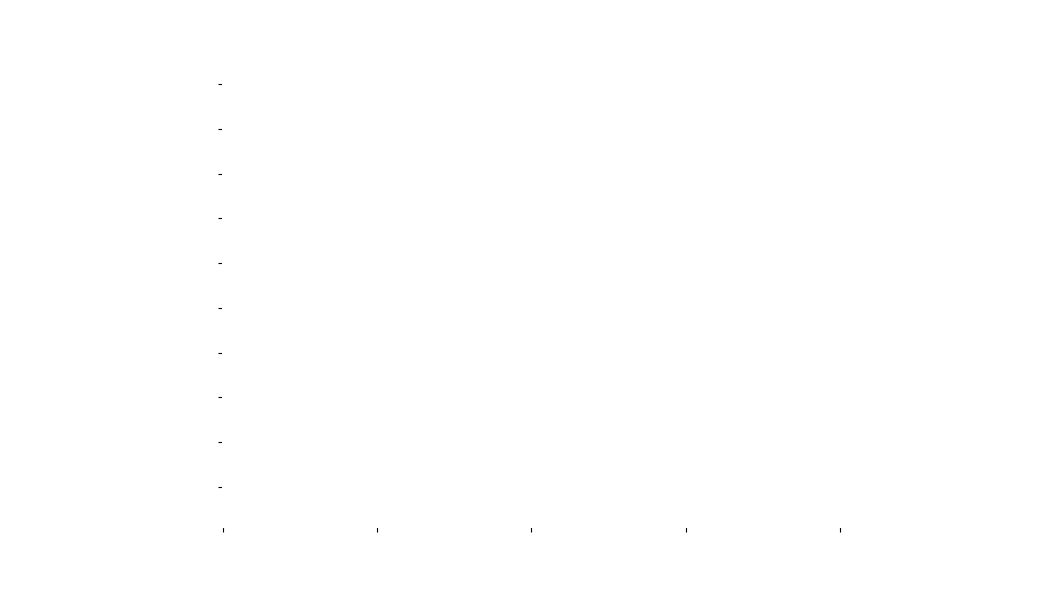

In [37]:
# Compute correlations for regression (numeric target)
correlation_regression = compute_correlations(df2, 'excess_return', task='regression', drop_targets=targets)
# Sort by absolute correlation strength and keep top 10
top10 = correlation_regression.reindex(
    correlation_regression['score'].abs().sort_values(ascending=False).index).head(10)
# Plot
plt.figure(figsize=(10, 6))
plt.gcf().patch.set_alpha(0)      
plt.gca().patch.set_alpha(0) 
plt.barh(top10['feature'], top10['score'], color="white")  
plt.xlabel('Correlation Score', color="white",fontsize=14,fontweight='bold')
plt.title('Top 10 Features Correlated with Excess Return', color="white",fontsize=24,fontweight='bold')
plt.xticks(color="white",fontsize=14,fontweight='bold')
plt.yticks(color="white",fontsize=14,fontweight='bold')
# White axis lines
ax = plt.gca()
ax.spines['top'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['right'].set_color('white')
# thicker axis lines
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()